In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [47]:
df = pd.read_csv("data.csv", delimiter='\t', low_memory=False)
df.head()

,Unnamed: 0,date,id,size_grp,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,...,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d,ret,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129
0,53170,9/30/1962,33814,mega,-0.4108911,0.3436155,0.0,-0.290922,-0.44744524,0.24796748,...,0.27476254,0.0,0.17842606,0.033875,0.0,0.017612524,NaN,NaN,NaN,NaN
1,53907,10/31/1962,33814,mega,-0.41374046,0.33333334,0.0,-0.281893,-0.44759825,0.23134328,...,0.21059783,0.0,0.13586956,0.094301,0.0,0.1242307722568512,NaN,NaN,NaN,NaN
2,54659,11/30/1962,33814,mega,-0.4017857,0.33169705,0.0,-0.297587,-0.4487909,0.2214854,...,0.1679947,0.0,0.1374502,0.111406,0.0,-0.01208981,NaN,NaN,NaN,NaN
3,55425,12/31/1962,33814,mega,-0.37068966,0.32225236,0.0,-0.309585,-0.4398085,0.21501926,...,0.12516046,0.0,0.1097561,0.194480,0.11369509,0.087412588,NaN,NaN,NaN,NaN
4,56207,1/31/1963,33814,mega,-0.36795145,0.32456142,0.0,-0.308729,-0.44189188,0.21082802,...,0.035714287,0.0,0.10841837,0.149682,0.08151476,-0.021864953,NaN,NaN,NaN,NaN


In [48]:
df.drop(columns=['Unnamed: 126', 'Unnamed: 127', 'Unnamed: 128', 'Unnamed: 129'], inplace=True)
df = df.iloc[:-2, :]
df = df.drop(index=range(122974, 122978))
df.drop(columns=['size_grp'], inplace=True)
df.dropna(inplace=True)
date = df['date']
print(date.shape)
df.drop(columns=['date'], inplace=True)

(122634,)


In [49]:
df.dropna(inplace=True)
print(df.shape)

(122634, 124)


In [50]:
df.to_csv("cleaned_data.csv", index=False)
date.to_csv("cleaned_date.csv", index=False)

Ridge Regression MSE (alpha=1.0): 0.0104


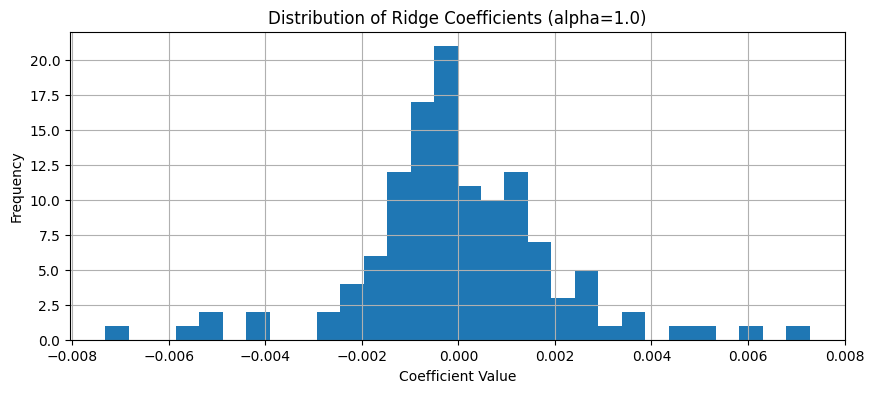

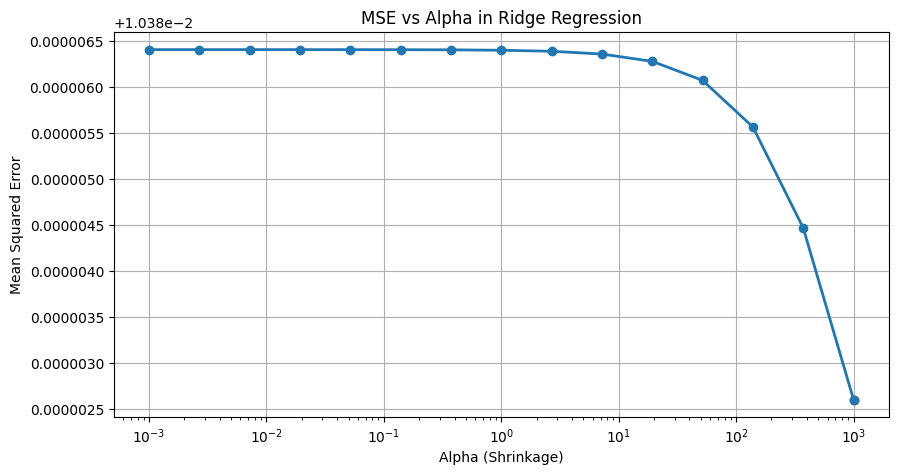

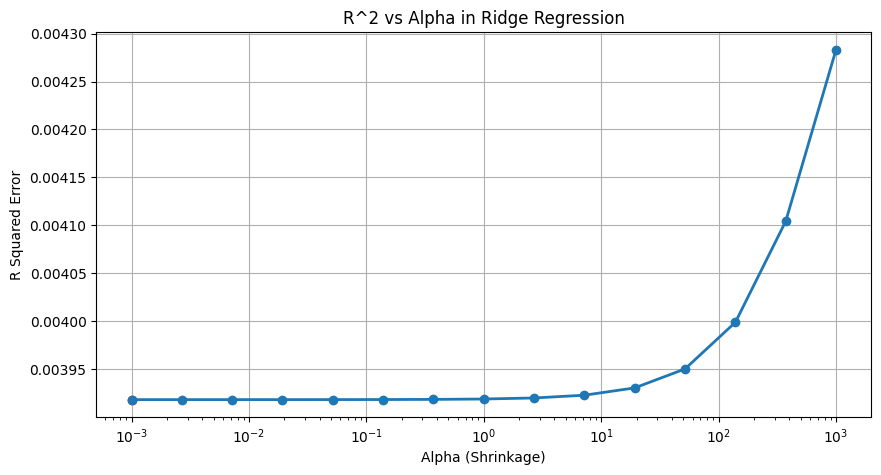

In [27]:
X_unscaled = df.drop(columns='ret')
X_unscaled = X_unscaled.apply(pd.to_numeric, errors='coerce')
X = (X_unscaled-X_unscaled.mean(axis=0))/X_unscaled.std(axis=0)

y = df['ret']
y = y.apply(pd.to_numeric, errors='coerce')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge regression with alpha=1.0
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

# Compute and print MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Ridge Regression MSE (alpha=1.0): {mse:.4f}")

# Plot distribution of coefficients
plt.figure(figsize=(10, 4))
plt.hist(ridge.coef_, bins=30)
plt.title("Distribution of Ridge Coefficients (alpha=1.0)")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Analyze effect of varying alpha
alphas = np.logspace(-3, 3, 15)
coefs = []
mses = []
rs = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    coefs.append(model.coef_)
    y_pred = model.predict(X_test)
    mses.append(mean_squared_error(y_test, y_pred))
    rs.append(r2_score(y_test, y_pred))


best_idx_ms = np.argmin(mses)
best_idx_rs = np.argmin(rs)

best_alpha_ms = alphas[best_idx_ms]
best_mse = mses[best_idx_ms]

best_alpha_rs = alphas[best_idx_rs]
best_rs = rs[best_idx_rs]

def plot(losses, best_loss, name_loss, abbrev, best_alpha, alphas):
    plt.figure(figsize=(10, 5))
    plt.plot(alphas, losses, marker='o', linewidth=2)
    plt.xscale("log")
    plt.xlabel("Alpha (Shrinkage)")
    plt.ylabel(name_loss)
    plt.title(abbrev + " vs Alpha in Ridge Regression")
    plt.grid(True)

    # Turn off scientific notation
    plt.ticklabel_format(style='plain', axis='y')
    
    # Annotate best point
    plt.scatter(best_alpha, best_loss, color='red')
    
    plt.show()


plot(mses, best_mse, 'Mean Squared Error', 'MSE', best_alpha_ms, alphas)
plot(rs, best_rs, 'R Squared Error', 'R^2', best_alpha_rs, alphas)



**Let us now do it mathematically to check Sklearn isn't playing any tricks on us !**

In [28]:
y.dtypes

dtype('float64')

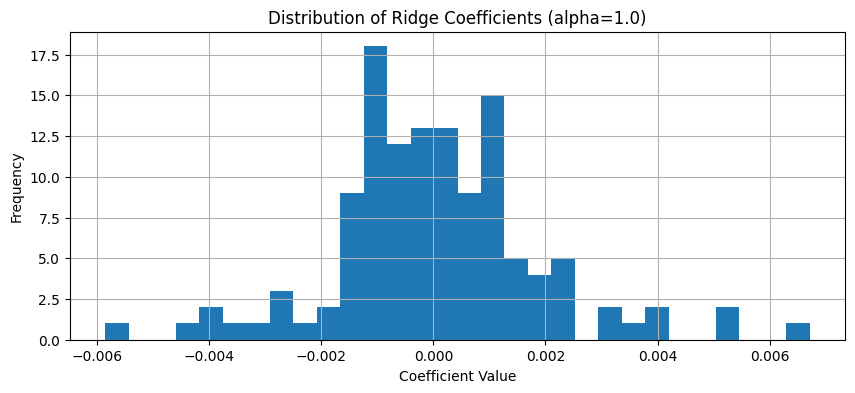

In [29]:
def ridge_reg(X, y, alpha, use_trick=False):
    if use_trick:
        # Inversion trick (better for tall matrices)
        n_samples = X.shape[0]
        A = np.matmul(X, X.T) + alpha * np.identity(n_samples)
        A_inv = np.linalg.inv(A)
        w = np.matmul(X.T, np.matmul(A_inv, y))
    else:
        # Standard ridge formula
        n_features = X.shape[1]
        A = np.matmul(X.T, X) + alpha * np.identity(n_features)
        A_inv = np.linalg.inv(A)
        w = np.matmul(A_inv, np.matmul(X.T, y))
    return w

w = ridge_reg(X, y, 1.0)

# Plot distribution of coefficients
plt.figure(figsize=(10, 4))
plt.hist(w, bins=30)
plt.title("Distribution of Ridge Coefficients (alpha=1.0)")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

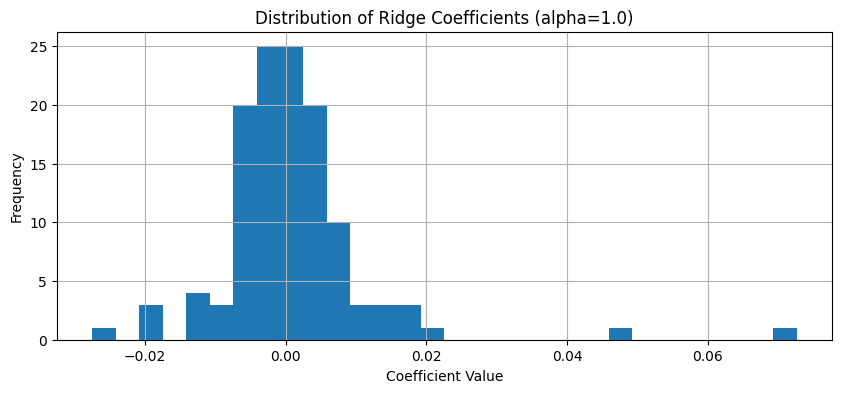

In [30]:
w = ridge_reg(X_unscaled, y, 1.0)

# Plot distribution of coefficients
plt.figure(figsize=(10, 4))
plt.hist(w, bins=30)
plt.title("Distribution of Ridge Coefficients (alpha=1.0)")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

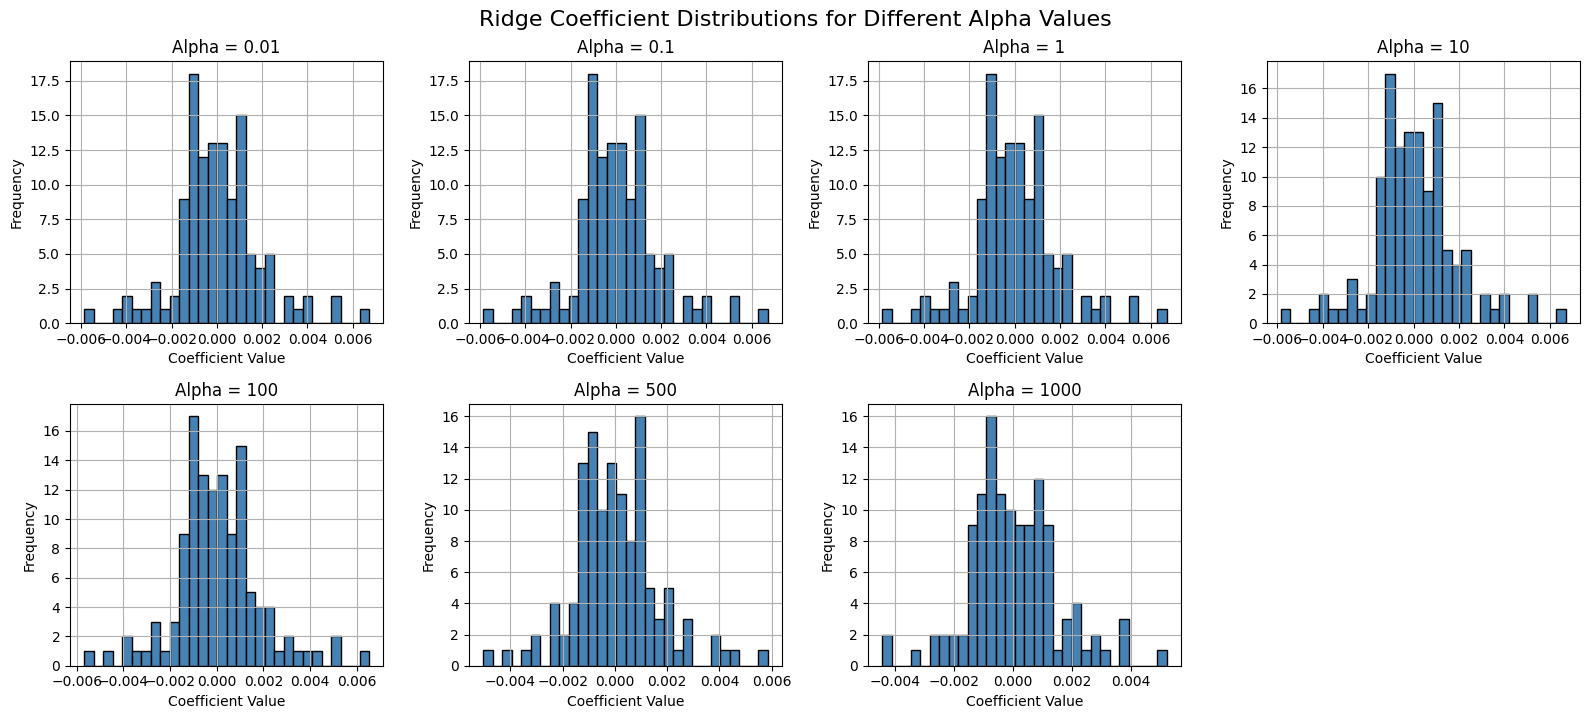

In [31]:
import numpy as np
import matplotlib.pyplot as plt


# Define a range of alphas
alphas = [0.01, 0.1, 1, 10, 100, 500, 1000]

# Store coefficients
weights = []

for alpha in alphas:
    w = ridge_reg(X, y, alpha)
    weights.append(w)

# Plot: Distributions of coefficients
n_cols = 4
n_rows = int(np.ceil(len(alphas) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))

for i, (alpha, w) in enumerate(zip(alphas, weights)):
    ax = axes.flat[i]
    ax.hist(w, bins=30, color='steelblue', edgecolor='black')
    ax.set_title(f'Alpha = {alpha}')
    ax.set_xlabel('Coefficient Value')
    ax.set_ylabel('Frequency')
    ax.grid(True)

# Hide unused subplots (if any)
for j in range(i+1, n_rows * n_cols):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.suptitle("Ridge Coefficient Distributions for Different Alpha Values", fontsize=16, y=1.02)
plt.show()


In [32]:
import time

alpha = 1.0
X_sampled, y_sampled = X.sample(n=30, random_state=42), y.loc[X.sample(n=30, random_state=42).index]


# Time standard method
start_std = time.time()
w_std = ridge_reg(X_sampled, y_sampled, alpha, use_trick=False)
end_std = time.time()

# Time inversion trick
start_trick = time.time()
w_trick = ridge_reg(X_sampled, y_sampled, alpha, use_trick=True)
end_trick = time.time()

print(f"Standard method took: {(end_std - start_std) * 1000:.2f} ms")
print(f"Inversion trick took: {(end_trick - start_trick) * 1000:.2f} ms")


Standard method took: 295.45 ms
Inversion trick took: 2.00 ms


In [33]:
import time

alpha = 1.0
X_sampled, y_sampled = X.sample(n=500, random_state=42), y.loc[X.sample(n=500, random_state=42).index]


# Time standard method
start_std = time.time()
w_std = ridge_reg(X_sampled, y_sampled, alpha, use_trick=False)
end_std = time.time()

# Time inversion trick
start_trick = time.time()
w_trick = ridge_reg(X_sampled, y_sampled, alpha, use_trick=True)
end_trick = time.time()

print(f"Standard method took: {(end_std - start_std) * 1000:.2f} ms")
print(f"Inversion trick took: {(end_trick - start_trick) * 1000:.2f} ms")


Standard method took: 278.67 ms
Inversion trick took: 1473.80 ms


In [34]:
date = pd.to_datetime(date, errors='coerce')

In [35]:
date.head()

0   1962-09-30
1   1962-10-31
2   1962-11-30
3   1962-12-31
4   1963-01-31
Name: date, dtype: datetime64[ns]

In [55]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge


#Added by Loris
def get_portfolio_weights(df, date, target_date, alpha=1.0, top_n=20):
    """
    Compute portfolio weights for stocks at a given date based on Ridge regression forecasts.
    
    Args:
        df (pd.DataFrame): Full dataset with 'date', 'id', 'ret', and features.
        date (str or pd.Timestamp): The current date for which to compute weights.
        target_date (str or pd.Timestamp): Date to build portfolio for.
        alpha (float): Ridge regularization strength.
        top_n (int): Number of stocks to include in portfolio (equal weights).
    
    Returns:
        pd.Series: Stock IDs as index, weights as values.
    """
    
    # Ensure 'date' is in datetime format
   
    print(type(pd.to_datetime(date)[0]))
    df['date'] = pd.to_datetime(date)
    
    
    # We start the time 0 as 1960-01-01
    start_date = pd.to_datetime('1960-01-01')
    print(df['date'].head())
    df['date'] = [(d.year-start_date.year)*365 + (d.month-start_date.month)*30 + (d.day-start_date.year) for d in df['date']]
    print(df['date'].head())
    #mean = df['date'].mean()
    #std = df['date'].std()
    #df['date'] = (df['date'] - mean)/std
    target = pd.to_datetime(target_date)
    target = (target.year-start_date.year)*365 + (target.month-start_date.month)*30 + (target.day-start_date.day)
    #target = target.astype('int64')/1e9
    #target = (target-mean)/std
    print(df['date'])
    print(target)
    
    # Split into training and testing based on 'date'

    train_df = df[df['date'] < target]
    #train_df['date'] = train_df['date'].astype('datetime64').astype(int).astype(float)
    #print(train_df.head())
    
    test_df = df[df['date'] >= target]
    #test['date'] = test_df['date'].astype('datetime64').astype(int).astype(float)
    #print(test_df.head())

    
    if train_df.empty or test_df.empty:
        raise ValueError("Not enough data for training or testing on this date.")

    # Select features (excluding 'ret', 'id', 'date')    
    ret = df.drop(columns=['ret'])
    df.drop(columns=['ret'], inplace=True)
    
    # Convert all features to numeric (if not already)
    X_train = train_df[df.columns].apply(pd.to_numeric, errors='coerce')
    X_test  = test_df[df.columns].apply(pd.to_numeric, errors='coerce')


    print(X_train.head())
    print(X_test.head())
    
    # Align y
    y_train = train_df['ret']
    
    # Drop NaNs in training data
    valid_rows_train = X_train.dropna().index
    X_train = X_train.loc[valid_rows_train]
    y_train = y_train.loc[valid_rows_train]

    # Drop NaNs in testing data
    valid_rows_test = X_test.dropna().index
    X_test = X_test.loc[valid_rows_test]
    test_ids = test_df.loc[X_test.index, 'id'].drop_duplicates()

    # Fit model
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Get top-N stock indices
    if len(y_pred) < top_n:
        top_n = len(y_pred)
    top_n_idx = np.argsort(y_pred)[-top_n:]

    # Select top-N unique IDs
    selected_ids = test_ids.iloc[top_n_idx].unique()
    
    # Create weights: 1/N for top, 0 for rest
    weights = pd.Series(0, index=selected_ids)
    weights.update(pd.Series(1 / top_n, index=selected_ids))
    
    return weights

# Example usage:
# Ensure 'df' is your full dataset and already cleaned
target_date = '2019-12-31'  # example date
df_test = df.copy(deep=True)
weights = get_portfolio_weights(df_test, date, target_date=pd.to_datetime(target_date), alpha=1.0, top_n=30)
print(weights.head(10))


<class 'pandas._libs.tslibs.timestamps.Timestamp'>
0   1962-09-30
1   1962-10-31
2   1962-11-30
3   1962-12-31
4   1963-01-31
Name: date, dtype: datetime64[ns]
0   -960
1   -929
2   -900
3   -869
4   -834
Name: date, dtype: int64
0          -960
1          -929
2          -900
3          -869
4          -834
          ...  
122973    21365
122978    21365
122979    21365
122980    21365
122981    21365
Name: date, Length: 122634, dtype: int64
21895


ValueError: Not enough data for training or testing on this date.